In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import warnings
warnings.filterwarnings("ignore")

df    = pd.read_csv("../data/credit_risk_clean.csv")
macro = pd.read_csv("../data/argentina_macro.csv")

print("Datos cargados OK")

Datos cargados OK


In [2]:
# El dataset no tiene fechas — simulamos distribución temporal realista
# 60% datos pre-crisis (2015-2020), 40% crisis (2021-2024)
np.random.seed(42)

years_pre    = list(range(2015, 2021))  # inflación < 55%
years_crisis = list(range(2021, 2025))  # inflación > 50%

n = len(df)
n_crisis = int(n * 0.40)
n_pre    = n - n_crisis

years_assigned = (
    np.random.choice(years_pre,    size=n_pre,    replace=True).tolist() +
    np.random.choice(years_crisis, size=n_crisis, replace=True).tolist()
)
np.random.shuffle(years_assigned)

df["year"] = years_assigned
df = df.merge(macro, on="year", how="left")

print("Distribución temporal asignada:")
print(df["year"].value_counts().sort_index())
print(f"\nInflación promedio asignada: {df['inflation_annual'].mean():.1f}%")

Distribución temporal asignada:
year
2015    3277
2016    3296
2017    3149
2018    3278
2019    3319
2020    3230
2021    3223
2022    3284
2023    3240
2024    3285
Name: count, dtype: int64

Inflación promedio asignada: 70.6%


In [3]:
# La clave del modelo: deflactar variables nominales
# En Argentina, ingresos nominales suben pero poder adquisitivo cae

# 1. Real income: ingreso ajustado por inflación acumulada
# Base 2015 = 100
inflation_cumulative = macro.copy()
inflation_cumulative["cum_factor"] = (
    (1 + inflation_cumulative["inflation_annual"] / 100).cumprod()
)

df = df.merge(
    inflation_cumulative[["year", "cum_factor"]],
    on="year", how="left"
)

# Ingreso real deflactado
df["real_income"] = df["person_income"] / df["cum_factor"]

# 2. Real interest burden: tasa del préstamo relativa a inflación
# Si inflación = 100% y tasa = 13%, la tasa real es NEGATIVA → menor riesgo real
df["real_interest_burden"] = df["loan_int_rate"] - df["inflation_annual"]

# 3. Inflation stress score: cuánto estrés macroeconómico enfrenta el deudor
df["inflation_stress"] = np.where(
    df["inflation_annual"] > 50,
    (df["inflation_annual"] - 50) / 100,
    0
)

# 4. Debt burden ajustado: deuda como % del ingreso real
df["real_debt_burden"] = df["loan_amnt"] / (df["real_income"] + 1)

print("Features ajustadas creadas:")
print(df[["person_income", "real_income", "loan_int_rate",
          "real_interest_burden", "inflation_stress",
          "real_debt_burden"]].describe().round(2))

Features ajustadas creadas:
       person_income  real_income  loan_int_rate  real_interest_burden  \
count       32581.00     32581.00       29465.00              29465.00   
mean        66074.85     17257.90          11.01                -59.60   
std         61983.12     25020.58           3.24                 54.73   
min          4000.00        30.54           5.42               -205.98   
25%         38500.00      2465.45           7.90                -83.81   
50%         55000.00      9271.71          10.99                -37.92   
75%         79200.00     23522.26          13.47                -24.68   
max       6000000.00    995925.76          23.22                 -1.58   

       inflation_stress  real_debt_burden  
count          32581.00          32581.00  
mean               0.28              4.33  
std                0.50              8.90  
min                0.00              0.00  
25%                0.00              0.33  
50%                0.01              0.84

In [4]:
data_adj = df.copy()

# Imputar nulos
data_adj["loan_int_rate"]     = data_adj["loan_int_rate"].fillna(data_adj["loan_int_rate"].median())
data_adj["person_emp_length"] = data_adj["person_emp_length"].fillna(data_adj["person_emp_length"].median())

# Encodear categóricas
le = LabelEncoder()
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]
for col in cat_cols:
    data_adj[col] = le.fit_transform(data_adj[col])

# Features ajustadas — incluyen variables macro
FEATURES_ADJ = [
    "person_age", "real_income", "person_home_ownership",
    "person_emp_length", "loan_intent", "loan_grade",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_default_on_file", "cb_person_cred_hist_length",
    "inflation_annual", "lending_rate",
    "real_interest_burden", "inflation_stress", "real_debt_burden"
]

X_adj = data_adj[FEATURES_ADJ]
y_adj = data_adj["loan_status"]

X_train_adj, X_test_adj, y_train_adj, y_test_adj = train_test_split(
    X_adj, y_adj, test_size=0.2, random_state=42, stratify=y_adj
)

rf_adjusted = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_adjusted.fit(X_train_adj, y_train_adj)

y_pred_adj       = rf_adjusted.predict(X_test_adj)
y_pred_proba_adj = rf_adjusted.predict_proba(X_test_adj)[:, 1]

auc_adjusted = roc_auc_score(y_test_adj, y_pred_proba_adj)

print("INFLATION-ADJUSTED MODEL — Random Forest")
print("=" * 55)
print(f"AUC-ROC: {auc_adjusted:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_pred_adj, y_test_adj,
      target_names=["No Default", "Default"]))

INFLATION-ADJUSTED MODEL — Random Forest
AUC-ROC: 0.8973

Classification Report:
              precision    recall  f1-score   support

  No Default       0.99      0.90      0.94      5628
     Default       0.60      0.96      0.74       889

    accuracy                           0.91      6517
   macro avg       0.80      0.93      0.84      6517
weighted avg       0.94      0.91      0.92      6517



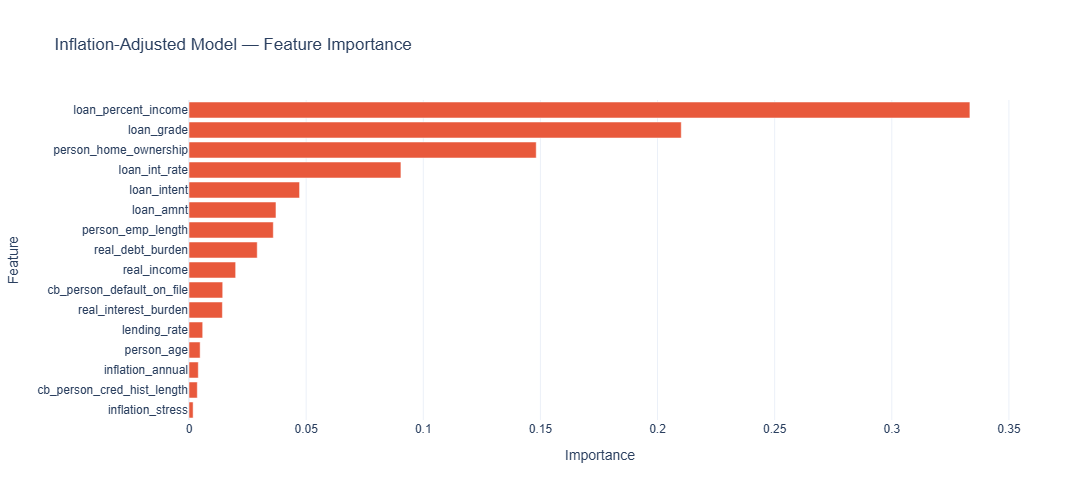

In [5]:
importance_adj = pd.DataFrame({
    "feature":    FEATURES_ADJ,
    "importance": rf_adjusted.feature_importances_
}).sort_values("importance", ascending=True)

fig = go.Figure(go.Bar(
    x=importance_adj["importance"],
    y=importance_adj["feature"],
    orientation="h",
    marker_color="#E8593C"
))

fig.update_layout(
    title="Inflation-Adjusted Model — Feature Importance",
    xaxis_title="Importance",
    yaxis_title="Feature",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=500
)

fig.show()

In [6]:
with open("../outputs/rf_adjusted.pkl", "wb") as f:
    pickle.dump(rf_adjusted, f)

adjusted_metrics = {
    "model": "Inflation-Adjusted RF",
    "auc":   round(auc_adjusted, 4)
}

metrics_df = pd.read_csv("../data/model_metrics.csv")
metrics_df = pd.concat([metrics_df, pd.DataFrame([adjusted_metrics])], ignore_index=True)
metrics_df.to_csv("../data/model_metrics.csv", index=False)

print("Guardado OK")
print(f"AUC Adjusted: {auc_adjusted:.4f}")

Guardado OK
AUC Adjusted: 0.8973
